In [156]:
#Bibitheken importieren

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [157]:
#Daten einlesen

daten = pd.read_csv("ai4i2020.csv")    # CSV-Datei in Variable "daten" einlesen

daten.head() #zeigt die ersten 5 Zeilen der Daten an um zu prüfen ob Daten korrekt eingelesen wurden

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [158]:
#zusätzliche Features erstellen

daten["temperatur_differenz"] = (daten["Process temperature [K]"] - daten["Air temperature [K]"])    # Temperaturunterschied zwischen Prozess und Umgebung

daten["verschleiss_last"] = (daten["Tool wear [min]"] * daten["Torque [Nm]"])    # Kombination aus Verschleiß und Belastung

daten["rpm_quadrat"] = (daten["Rotational speed [rpm]"] ** 2)

# Quadratisches Feature für Temperaturdifferenz
daten["temperatur_differenz_quadrat"] = (daten["temperatur_differenz"] ** 2)

# Interaktion: Drehzahl mal Temperaturdifferenz
daten["rpm_mal_temperatur_differenz"] = (daten["Rotational speed [rpm]"] * daten["temperatur_differenz"])

In [159]:
#Welche Spalte soll vorhergesagt werden und welche Features sollen verwendet werden

zielspalte = "HDF"

erstes_feature = "rpm_quadrat"    #mehr Drehzahl führt zu höherer temperatur, was die Wahrscheinlichkeit eines HDF erhöht

zweites_feature = "rpm_mal_temperatur_differenz"   #je größer die Differenz zwischen Prozess- und Umgebungstemperatur, desto höher die Wahrscheinlichkeit eines HDF


lernrate = 0.5

anzahl_durchlaeufe = 50000

schwellenwert = 0.06

gewicht_klasse_0 = 1

gewicht_klasse_1 = 50

In [160]:
# Daten für die Modellierung auswählen

ausgewaehlte_daten = daten[[erstes_feature, zweites_feature, zielspalte]].copy()

In [161]:
#X- und y-Werte für die Modellierung erstellen

x_werte = ausgewaehlte_daten[[erstes_feature, zweites_feature]].values    # X-Werte = Eingabefeatures

y_werte = ausgewaehlte_daten[zielspalte].values    # y-Werte = Zielvariable

In [162]:
#Features standardisieren

mittelwerte = x_werte.mean(axis=0)    # Mittelwerte der Features berechnen (axis=0 bedeutet, dass die Mittelwerte für jede Spalte berechnet werden)

standardabweichungen = x_werte.std(axis=0)    # Standardabweichungen der Features berechnen

x_standardisiert = (x_werte - mittelwerte) / standardabweichungen    # Features standardisieren (z-Transformation)


In [163]:
#Designmatrix erstellen

einsen_spalte = np.ones((x_standardisiert.shape[0], 1))    # Spalte mit Einsen erstellen (später für theta0)

designmatrix = np.hstack([einsen_spalte,x_standardisiert])    # Designmatrix erstellen (Einsenspalte + standardisierte Features)

In [164]:
#startwerte für die Parameter (theta) festlegen

anzahl_parameter = designmatrix.shape[1]    # Anzahl der Parameter (Anzahl der Spalten in der Designmatrix) bestimmen

theta = np.zeros(anzahl_parameter)    # Parametervektor (theta) mit Nullen initialisieren (Anzahl der Parameter entspricht Anzahl der Spalten in der Designmatrix bzw. Anzahl der Features + 1 für theta0)


In [165]:
#sigmoid-Funktion

def sigmoid(wert):

    wert = np.clip(wert, -500, 500)    # Wert in einem Bereich begrenzen, um Überlauf zu vermeiden (np.exp(-wert) könnte sonst zu groß werden)

    return 1 / (1 + np.exp(-wert))    # Sigmoid-Funktion berechnen (1 / (1 + e^(-wert))) und zurückgeben

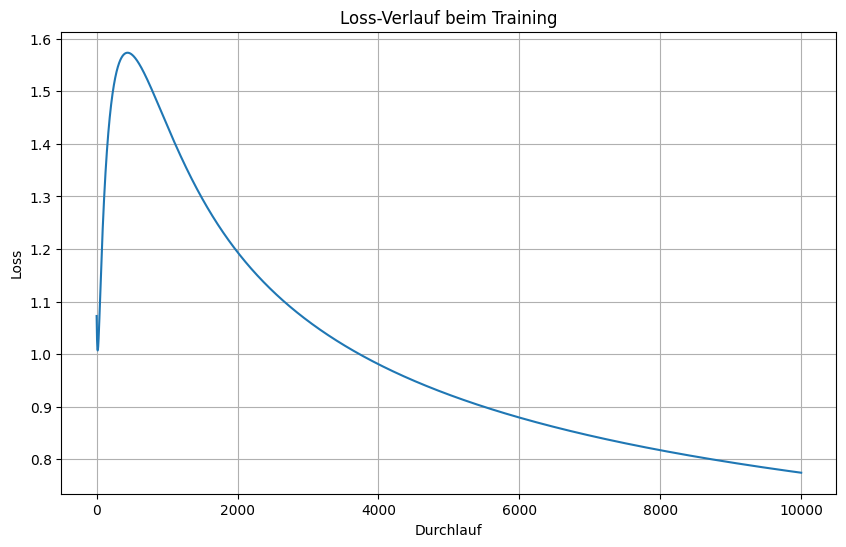

In [166]:
#Lossfunktion berechnen

def gewichtete_lossfunktion(designmatrix,zielwerte,parametervektor):

    linearkombination = (designmatrix @ parametervektor)    # Linearkombination aus Designmatrix und Parametervektor berechnen (z = X @ theta), für jede Zeile der Designmatrix wird die Linearkombination aus den Features und den Parametern berechnet (theta0 * 1 + theta1 * feature1 + theta2 * feature2 + ...)

    vorhergesagte_wahrscheinlichkeiten = sigmoid(linearkombination)    #Sigmoidfunktion anwenden, um die Linearkombination in Wahrscheinlichkeiten umzuwandeln (p = sigmoid(z)), große positive Werte von z führen zu p nahe 1, große negative Werte von z führen zu p nahe 0

    Grenze = 1e-15    

    vorhergesagte_wahrscheinlichkeiten = np.clip(vorhergesagte_wahrscheinlichkeiten,Grenze,1 - Grenze)    # Vorhersagen in einem Bereich begrenzen, um log(0) zu vermeiden (np.log(0) wäre mathematisch nicht definiert)


    gewichtung = np.where(zielwerte == 1,gewicht_klasse_1,gewicht_klasse_0)    # Gewichtung für jede Zeile bestimmen (np.where(condition, value_if_true, value_if_false)), wenn der Zielwert 1 ist, wird das Gewicht für Klasse 1 zugewiesen, ansonsten das Gewicht für Klasse 0


    loss = -np.mean(gewichtung * (zielwerte * np.log(vorhergesagte_wahrscheinlichkeiten) + (1 - zielwerte) * np.log(1 - vorhergesagte_wahrscheinlichkeiten))) # -( y * log(p)+ (1-y) * log(1-p) ) binary cross-entropy loss berechnen

    return loss    # Loss zurückgeben

#plotten des Loss-Verlaufs
plt.figure(figsize=(10, 6))

plt.plot(loss_verlauf)

plt.xlabel("Durchlauf")

plt.ylabel("Loss")

plt.title("Loss-Verlauf beim Training")

plt.grid()

plt.show()


In [167]:
#Gradientenvektor berechnen

def gradient_berechnen(designmatrix,zielwerte,parametervektor):

    anzahl_beobachtungen = len(zielwerte)    # Anzahl der Datenpunkte bestimmen (len(...) zählt, wie viele Zeilen / Beobachtungen im Datensatz vorhanden sind)

    linearkombination = (designmatrix @ parametervektor)    # Matrix-Vektor-Produkt aus Designmatrix und Parametervektor berechnen, um die Linearkombination (z) für alle Datenpunkte zu erhalten

    vorhergesagte_wahrscheinlichkeiten = sigmoid(linearkombination)    # Sigmoidfunktion anwenden, um die Linearkombination in Wahrscheinlichkeiten umzuwandeln (p = sigmoid(z)), große positive Werte von z führen zu p nahe 1, große negative Werte von z führen zu p nahe 0

    fehler = (vorhergesagte_wahrscheinlichkeiten - zielwerte)    # Fehler berechnen (vorhergesagte Wahrscheinlichkeiten - tatsächliche Zielwerte), für jeden Datenpunkt wird die Differenz zwischen der vorhergesagten Wahrscheinlichkeit und dem tatsächlichen Zielwert berechnet

    gradienten_vektor = (1 / anzahl_beobachtungen) * (designmatrix.T @ fehler)    # Gradientenvektor berechnen (1/m * X^T @ Fehler), Designmatrix transponieren (X^T) und mit Fehler multiplizieren, dann durch Anzahl der Beobachtungen teilen, um den Durchschnittsgradienten zu erhalten

    return gradienten_vektor    # Gradientenvektor zurückgeben

In [168]:
#Modelltraining mit Gradient Descent

def modell_trainieren(designmatrix,zielwerte,parametervektor,lernrate,anzahl_durchlaeufe):

    loss_verlauf = []    # Hier speichern wir später jeden Loss-Wert, damit können wir kontrollieren, ob das Modell besser wird


    for durchlauf in range(anzahl_durchlaeufe):     # Diese Schleife wiederholt das Lernen mehrfach

        gradienten_vektor = gradient_berechnen(designmatrix,zielwerte,parametervektor) # 1. Aktuellen Gradienten berechnen (Gradientenvektor berechnen, der angibt, in welche Richtung die Parameter angepasst werden müssen, um den Loss zu minimieren)

        parametervektor = (parametervektor - lernrate * gradienten_vektor)    # 2. Parameter anpassen (Parametervektor aktualisieren, indem der Gradientenvektor mit der Lernrate multipliziert und von den aktuellen Parametern subtrahiert wird, um in Richtung des Minimums zu gehen)

        aktueller_loss = gewichtete_lossfunktion(designmatrix,zielwerte,parametervektor)    # 3. Neuen Loss berechnen, um zu sehen, ob die Anpassung der Parameter den Loss verringert hat (Lossfunktion mit den aktualisierten Parametern aufrufen)

        loss_verlauf.append(aktueller_loss)    # 4. Loss speichern (Loss-Verlauf aktualisieren, damit wir später sehen können, ob der Loss kleiner wird)

    return parametervektor, loss_verlauf    # Am Ende geben wir zurück: 1. die gelernten Theta-Werte, 2. den gesamten Loss-Verlauf

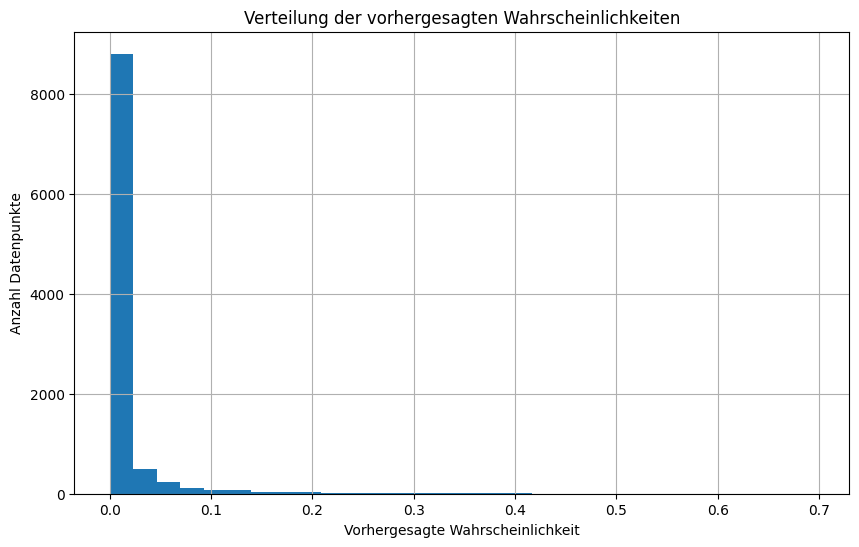

In [169]:
#Vorhersagen berechnen

def vorhersagen_berechnen(designmatrix,parametervektor,schwellenwert):

    linearkombination = (designmatrix @ parametervektor)    # Matrix-Vektor-Produkt aus Designmatrix und Parametervektor berechnen, um die Linearkombination (z) für alle Datenpunkte zu erhalten

    vorhergesagte_wahrscheinlichkeiten = sigmoid(linearkombination)    # Sigmoidfunktion anwenden, um die Linearkombination in Wahrscheinlichkeiten umzuwandeln (p = sigmoid(z)), große positive Werte von z führen zu p nahe 1, große negative Werte von z führen zu p nahe 0

    vorhergesagte_klassen = (vorhergesagte_wahrscheinlichkeiten >= schwellenwert).astype(int)    #wenn die vorhergesagte Wahrscheinlichkeit größer oder gleich dem Schwellenwert ist, wird die Vorhersage als Klasse 1 (positiv) klassifiziert, andernfalls als Klasse 0 (negativ), .astype(int) konvertiert die booleschen Werte in 0 und 1

    return vorhergesagte_wahrscheinlichkeiten, vorhergesagte_klassen    # Vorhersagen zurückgeben: 1. die vorhergesagten Wahrscheinlichkeiten, 2. die vorhergesagten Klassen basierend auf dem Schwellenwert


#Verteilung der vorhergesagten Wahrscheinlichkeiten plotten
plt.figure(figsize=(10, 6))

plt.hist(wahrscheinlichkeiten,bins=30)

plt.xlabel("Vorhergesagte Wahrscheinlichkeit")

plt.ylabel("Anzahl Datenpunkte")

plt.title("Verteilung der vorhergesagten Wahrscheinlichkeiten")

plt.grid()

plt.show()

In [170]:
#Confusion Matrix berechnen

def confusion_matrix_berechnen(echte_klassen,vorhergesagte_klassen):

    richtig_negativ = np.sum((echte_klassen == 0)&(vorhergesagte_klassen == 0))    #true negative berechnen, indem gezählt wird, wie viele Datenpunkte tatsächlich Klasse 0 sind und auch als Klasse 0 vorhergesagt wurden

    falsch_positiv = np.sum((echte_klassen == 0) & (vorhergesagte_klassen == 1))    #false positive berechnen, indem gezählt wird, wie viele Datenpunkte tatsächlich Klasse 0 sind, aber als Klasse 1 vorhergesagt wurden

    falsch_negativ = np.sum((echte_klassen == 1) & (vorhergesagte_klassen == 0))    #false negative berechnen, indem gezählt wird, wie viele Datenpunkte tatsächlich Klasse 1 sind, aber als Klasse 0 vorhergesagt wurden

    richtig_positiv = np.sum((echte_klassen == 1) & (vorhergesagte_klassen == 1))    #true positive berechnen, indem gezählt wird, wie viele Datenpunkte tatsächlich Klasse 1 sind und auch als Klasse 1 vorhergesagt wurden


    return richtig_negativ, falsch_positiv, falsch_negativ, richtig_positiv    # confusion matrix Werte zurückgeben: 1. true negative, 2. false positive, 3. false negative, 4. true positive

In [171]:
#F1-Score berechnen

def f1_score_berechnen(falsch_positiv,falsch_negativ,richtig_positiv):

  
    precision = richtig_positiv / (richtig_positiv + falsch_positiv)    # Precision: von allen vorhergesagten Ausfällen: Wie viele waren wirklich Ausfälle? (Precision = true positives / (true positives + false positives))

    recall = richtig_positiv / (richtig_positiv + falsch_negativ)    # Recall: von allen echten Ausfällen: Wie viele hat das Modell erkannt (Recall = true positives / (true positives + false negatives))


    
    f1_score = 2 * precision * recall / (precision + recall)    # F1-Score: Kombiniert Precision und Recall (F1 = 2 * (Precision * Recall) / (Precision + Recall)), gibt eine harmonische Mittelwert von Precision und Recall zurück, um die Balance zwischen beiden zu bewerten


    return precision, recall, f1_score    # Precision, Recall und F1-Score zurückgeben

In [172]:
#loss zu Beginn berechnen
start_loss = gewichtete_lossfunktion(designmatrix,y_werte,theta)

#gradientenvektor zu Beginn berechnen
start_gradient = gradient_berechnen(designmatrix,y_werte,theta)

#modell trainieren
trainierter_parametervektor, loss_verlauf = modell_trainieren(designmatrix,y_werte,theta,lernrate,anzahl_durchlaeufe)

#Vorhersagen berechnen
wahrscheinlichkeiten, vorhergesagte_klassen = vorhersagen_berechnen(designmatrix,trainierter_parametervektor,schwellenwert)

#Confusion Matrix berechnen
richtig_negativ, falsch_positiv, falsch_negativ, richtig_positiv = confusion_matrix_berechnen(y_werte,vorhergesagte_klassen)

#F1-Score berechnen
precision, recall, f1_score = f1_score_berechnen(falsch_positiv,falsch_negativ,richtig_positiv)


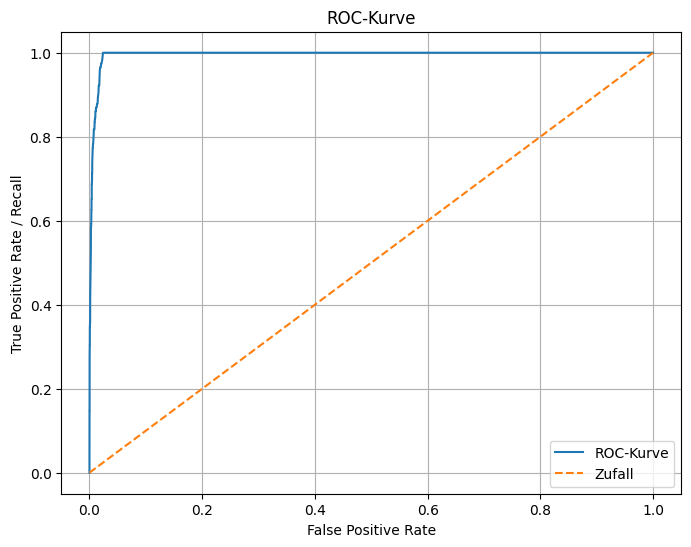

In [173]:
#ROC-Kurve erstellen

schwellenwerte_roc = np.linspace(0, 1, 200)

tpr_werte = []
fpr_werte = []

for aktueller_schwellenwert in schwellenwerte_roc:

    klassen_test = (wahrscheinlichkeiten >= aktueller_schwellenwert).astype(int)

    richtig_negativ, falsch_positiv, falsch_negativ, richtig_positiv = confusion_matrix_berechnen(y_werte,klassen_test)

    if richtig_positiv + falsch_negativ == 0:
        tpr = 0
    else:
        tpr = richtig_positiv / (richtig_positiv + falsch_negativ)

    if falsch_positiv + richtig_negativ == 0:
        fpr = 0
    else:
        fpr = falsch_positiv / (falsch_positiv + richtig_negativ)

    tpr_werte.append(tpr)
    fpr_werte.append(fpr)


plt.figure(figsize=(8, 6))

plt.plot(fpr_werte, tpr_werte, label="ROC-Kurve")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Zufall"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC-Kurve")

plt.legend()
plt.grid()
plt.show()

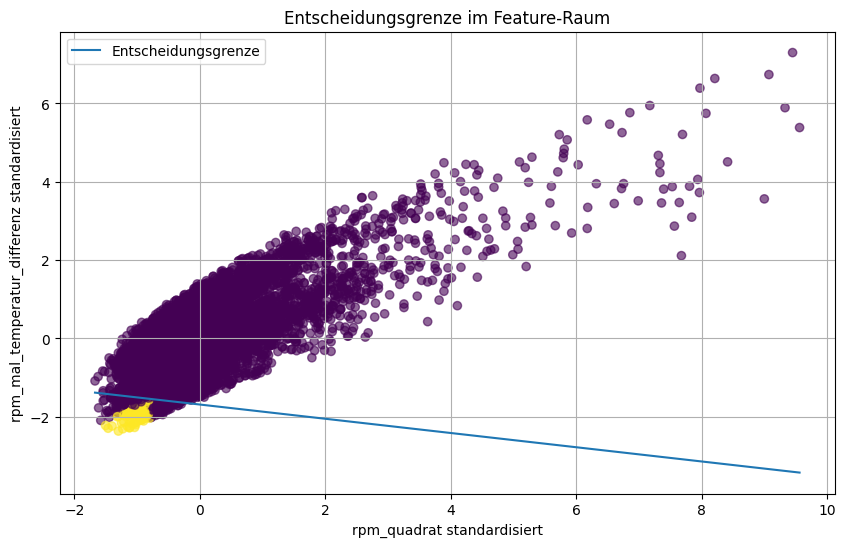

In [174]:
#Entscheidungsgrenze im Feature-Raum darstellen

theta0 = trainierter_parametervektor[0]
theta1 = trainierter_parametervektor[1]
theta2 = trainierter_parametervektor[2]

x1_linie = np.linspace(x_standardisiert[:, 0].min(),x_standardisiert[:, 0].max(),100)

# Grenze bei p = 0.5 bedeutet z = 0
# Logit-Grenze für deinen echten Schwellenwert berechnen
grenze_logit = np.log(schwellenwert / (1 - schwellenwert))

# Entscheidungsgrenze für diesen Schwellenwert berechnen
x2_linie = (grenze_logit - theta0 - theta1 * x1_linie) / theta2

plt.figure(figsize=(10, 6))

plt.scatter(x_standardisiert[:, 0],x_standardisiert[:, 1],c=y_werte,alpha=0.6)

plt.plot(x1_linie,x2_linie,label="Entscheidungsgrenze")

plt.xlabel(erstes_feature + " standardisiert")
plt.ylabel(zweites_feature + " standardisiert")
plt.title("Entscheidungsgrenze im Feature-Raum")

plt.legend()
plt.grid()
plt.show()

In [175]:
# TESTZEILE




print(start_loss)

print(start_gradient)



print("Trainierte Theta-Werte:")
print(trainierter_parametervektor)

print("Erster Loss:")
print(loss_verlauf[0])

print("Letzter Loss:")
print(loss_verlauf[-1])


print("Erste 10 Wahrscheinlichkeiten:")
print(wahrscheinlichkeiten[:10])

print("Erste 10 vorhergesagte Klassen:")
print(vorhergesagte_klassen[:10])


print("Richtig Negativ:", richtig_negativ)
print("Falsch Positiv:", falsch_positiv)
print("Falsch Negativ:", falsch_negativ)
print("Richtig Positiv:", richtig_positiv)


print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1_score)


print("Maximale Wahrscheinlichkeit:")
print(np.max(wahrscheinlichkeiten))


1.0837356168054746
[0.4885     0.01131836 0.02150896]
Trainierte Theta-Werte:
[-16.48346354  -1.4804929   -8.15061548]
Erster Loss:
1.0365317759048822
Letzter Loss:
0.5253098342855894
Erste 10 Wahrscheinlichkeiten:
[2.99454887e-09 1.52415644e-06 5.13735044e-08 8.49867774e-07
 1.52415644e-06 7.30255390e-07 2.20164501e-09 8.58149357e-09
 3.17216493e-11 6.52283799e-13]
Erste 10 vorhergesagte Klassen:
[0 0 0 0 0 0 0 0 0 0]
Richtig Negativ: 9885
Falsch Positiv: 0
Falsch Negativ: 115
Richtig Positiv: 0
Precision: 0.35331230283911674
Recall: 0.9739130434782609
F1-Score: 0.5185185185185185
Maximale Wahrscheinlichkeit:
0.9908679984871624
